# Setup D: inclined pipe effective sample size estimate

## 1. Title and purpose

This notebook develops a first-order engineering model for **Setup D**, an inclined powder pipe with an NIR diffuse reflectance probe mounted in the lower part of the pipe. The objective is to estimate a **flow-based effective sample size estimate** during one spectrum acquisition.

The result is best interpreted as a **gross refreshed optical mass / effective sample size estimate**. It is not a full radiative-transfer model, not a particulate sampling-theory model, and not a validated estimate of independent sample mass.

## 2. Scientific background

### NIR diffuse reflectance analysis of powders

In diffuse reflectance NIR measurements, light enters a powder bed, interacts with particles over a limited depth, and a fraction of the scattered light returns to the detector. The measured spectrum therefore reflects an **optically weighted near-surface volume** rather than the entire bulk stream.

### Why use a simple optical interaction approximation?

For engineering comparisons, it is often useful to approximate the optical interaction region with a simple geometric volume. Here, the optical sampling region is approximated as a cylinder with:

- cross-sectional area equal to the probe window footprint
- depth equal to an assumed light penetration depth

This simplification ignores depth-dependent photon weighting, scattering anisotropy, particle packing effects, and spectral absorption details, but it provides a practical way to compare conditions.

### Why moving powder increases the sampled mass during one acquisition

If powder continuously moves past the probe during one acquisition, the optical interaction zone is refreshed. Faster renewal means that more powder volume can pass through the probe footprint during the acquisition period. That does not guarantee statistical independence of all material seen by the instrument, but it increases the gross refreshed optical mass available to contribute to the measurement.

### Why Setup D differs from other geometries

Setup D differs from a **static powder bed** because the material in front of the probe is continuously replaced. It also differs from a **mechanically refreshed geometry such as the spiderwheel** because the refresh mechanism is not imposed by discrete compartments or controlled mechanical presentation. Instead, it is driven by gravity-assisted powder transport through a tilted pipe.

### Why a superficial velocity model is useful

A practical first approximation is to connect throughput, bulk density, and pipe cross-sectional area to a **superficial bulk velocity**. This gives a simple estimate of how quickly powder is renewed in front of the probe. In reality, the local flow at the lower wall of a tilted pipe may differ substantially from the cross-sectional average, but the superficial velocity remains a useful baseline for sensitivity analysis and engineering intuition.

In [13]:
# 6. Imports
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

In [14]:
# 7. User-defined parameters

pipe_diameter_mm = 65.0  # Pipe internal diameter [mm]
pipe_tilt_deg_from_vertical = 26.5  # Pipe axis tilt from vertical [deg]
pipe_total_height_mm = 340.0  # Total height of the pipe [mm]
pipe_inlet_outlet_displacement_mm = 100.2  # Horizontal displacement from inlet to outlet center [mm]
probe_diameter_mm = 5.0  # NIR probe window diameter [mm]
acquisition_time_s = 1.8  # Spectrum acquisition time [s]

throughput_values_kg_h = list(range(40, 101, 5))  # Throughput sweep [kg/h]
density_values_g_cm3 = [0.4, 0.5, 0.6]  # Bulk density scenarios [g/cm^3]
penetration_depth_values_mm = np.round(np.arange(0.1, 2.0 + 0.1, 0.1), 1)  # Penetration depth sweep [mm]

worked_example_throughput_kg_h = 95.0  # Worked example throughput [kg/h]
worked_example_density_g_cm3 = 0.4  # Worked example bulk density [g/cm^3]

worked_example_penetration_depth_mm = 1.0  # Worked example penetration depth [mm]

In [ ]:
display(Markdown(
    f"## 3. Setup D device description\n\n"
    f"Setup D is modeled as follows:\n\n"
    f"- pipe internal diameter = **{pipe_diameter_mm:.0f} mm**\n"
    f"- pipe axis tilted **{pipe_tilt_deg_from_vertical} degrees from vertical**\n"
    f"- total height of the pipe = **{pipe_total_height_mm:.0f} mm**\n"
    f"- horizontal displacement from inlet to outlet center = **{pipe_inlet_outlet_displacement_mm} mm**\n"
    f"- powder enters from above and moves downward toward the outlet\n"
    f"- due to the tilt, powder is expected to slide preferentially along the **lower side of the pipe**\n"
    f"- the NIR probe is mounted in the **lower part of the pipe**\n"
    f"- the probe window is assumed to be **continuously covered by powder**\n"
    f"- the effective sample size estimate therefore depends primarily on **powder renewal in front of the probe**\n\n"
    f"This notebook uses a **first-order flow approximation**. The {pipe_tilt_deg_from_vertical} degree tilt is included as part of the physical setup description and qualitative interpretation, but the base model still estimates renewal from the total throughput, bulk density, and full pipe cross-sectional area.\n\n"
    f"### Powder state at the probe window\n\n"
    f"The physical state of the powder in front of the probe has direct consequences for the optical measurement and for the interpretation of the effective sample size estimate.\n\n"
    f"**Flow regime.** At {pipe_tilt_deg_from_vertical} degrees from vertical the gravitational component along the pipe axis is "
    f"$g \\cos({pipe_tilt_deg_from_vertical}°) \\approx {{8.8}}\\;\\mathrm{{m/s^2}}$, "
    f"which is large enough to sustain continuous gravity-driven flow for most free-flowing powders. "
    f"The transverse gravitational component $g \\sin({pipe_tilt_deg_from_vertical}°) \\approx {{4.4}}\\;\\mathrm{{m/s^2}}$ "
    f"pushes the flowing material toward the lower pipe wall where the probe is located. "
    f"Under the throughput range considered here (40–100 kg/h), the resulting superficial velocities in a {pipe_diameter_mm:.0f} mm pipe "
    f"are on the order of 0.4–1.6 cm/s, which corresponds to a slow, dense-phase sliding regime rather than a dilute suspension or fast pneumatic transport.\n\n"
    f"**Packing state.** Because the powder slides under gravity rather than being pneumatically conveyed or mechanically agitated, "
    f"the material in front of the probe is expected to be in a relatively dense, settled state. This is closer to a loosely packed bed "
    f"than to an aerated or fluidized condition. The term \"fluffy\" would not be appropriate for the baseline operating assumption; "
    f"the powder layer at the probe window is better described as a gently moving packed or semi-packed layer.\n\n"
    f"**Wall contact and coverage.** The transverse gravity component ensures that powder is pressed against the lower wall where the "
    f"probe is mounted. At typical operating throughputs the probe window is expected to remain continuously covered. At very low "
    f"throughputs, however, intermittent or slug-like flow could occur, leading to periods of partial coverage or temporary exposure "
    f"of the probe window. The model does not account for such intermittent behavior.\n\n"
    f"**Compaction and consolidation.** In an inclined pipe of this length, the overburden pressure from the column of material above "
    f"the probe may cause mild consolidation of the powder layer near the lower wall. The local bulk density at the probe could therefore "
    f"be slightly higher than the nominal bulk density used in the model. This effect is expected to be small for a {pipe_total_height_mm:.0f} mm pipe "
    f"at moderate throughputs.\n\n"
    f"**Shear and velocity profile.** The flow velocity profile across the pipe cross-section is not uniform. Material near the lower "
    f"wall may move more slowly than the average superficial velocity due to wall friction, while material on the free surface of the "
    f"flowing layer may move faster. The probe therefore sees the slower-moving fraction, which could reduce the effective renewal rate "
    f"compared to the superficial velocity estimate.\n\n"
    f"**Aeration and de-aeration.** If the powder is fed from a hopper or feeder that introduces some air, it may enter the pipe in a "
    f"partially aerated state. As it travels through the pipe, gravity and compaction tend to de-aerate the material. By the time it "
    f"reaches the probe, the powder is likely closer to a tapped or settled condition than to an aerated one.\n\n"
    f"**Implications for the model.** These considerations suggest that the superficial velocity used in the base model may overestimate "
    f"the local renewal rate at the probe position, because the probe sits in a slower-moving wall region with denser packing. A future "
    f"refinement could introduce a wall velocity correction factor or an effective flowing-layer model to account for this."
))

## 3. Setup D device description

Setup D is modeled as follows:

- pipe internal diameter = **65 mm**
- pipe axis tilted **26.5 degrees from vertical**
- total height of the pipe = **340 mm**
- horizontal displacement from inlet to outlet center = **100.2 mm**
- powder enters from above and moves downward toward the outlet
- due to the tilt, powder is expected to slide preferentially along the **lower side of the pipe**
- the NIR probe is mounted in the **lower part of the pipe**
- the probe window is assumed to be **continuously covered by powder**
- the effective sample size proxy therefore depends primarily on **powder renewal in front of the probe**

This notebook uses a **first-order flow approximation**. The 26.5 degree tilt is included as part of the physical setup description and qualitative interpretation, but the base model still estimates renewal from the total throughput, bulk density, and full pipe cross-sectional area.

### Powder state at the probe window

The physical state of the powder in front of the probe has direct consequences for the optical measurement and for the interpretation of the effective sample size proxy.

**Flow regime.** At 26.5 degrees from vertical the gravitational component along the pipe axis is $g \cos(26.5°) \approx {8.8}\;\mathrm{m/s^2}$, which is large enough to sustain continuous gravity-driven flow for most free-flowing powders. The transverse gravitational component $g \sin(26.5°) \approx {4.4}\;\mathrm{m/s^2}$ pushes the flowing material toward the lower pipe wall where the probe is located. Under the throughput range considered here (40–100 kg/h), the resulting superficial velocities in a 65 mm pipe are on the order of 0.4–1.6 cm/s, which corresponds to a slow, dense-phase sliding regime rather than a dilute suspension or fast pneumatic transport.

**Packing state.** Because the powder slides under gravity rather than being pneumatically conveyed or mechanically agitated, the material in front of the probe is expected to be in a relatively dense, settled state. This is closer to a loosely packed bed than to an aerated or fluidized condition. The term "fluffy" would not be appropriate for the baseline operating assumption; the powder layer at the probe window is better described as a gently moving packed or semi-packed layer.

**Wall contact and coverage.** The transverse gravity component ensures that powder is pressed against the lower wall where the probe is mounted. At typical operating throughputs the probe window is expected to remain continuously covered. At very low throughputs, however, intermittent or slug-like flow could occur, leading to periods of partial coverage or temporary exposure of the probe window. The model does not account for such intermittent behavior.

**Compaction and consolidation.** In an inclined pipe of this length, the overburden pressure from the column of material above the probe may cause mild consolidation of the powder layer near the lower wall. The local bulk density at the probe could therefore be slightly higher than the nominal bulk density used in the model. This effect is expected to be small for a 340 mm pipe at moderate throughputs.

**Shear and velocity profile.** The flow velocity profile across the pipe cross-section is not uniform. Material near the lower wall may move more slowly than the average superficial velocity due to wall friction, while material on the free surface of the flowing layer may move faster. The probe therefore sees the slower-moving fraction, which could reduce the effective renewal rate compared to the superficial velocity estimate.

**Aeration and de-aeration.** If the powder is fed from a hopper or feeder that introduces some air, it may enter the pipe in a partially aerated state. As it travels through the pipe, gravity and compaction tend to de-aerate the material. By the time it reaches the probe, the powder is likely closer to a tapped or settled condition than to an aerated one.

**Implications for the model.** These considerations suggest that the superficial velocity used in the base model may overestimate the local renewal rate at the probe position, because the probe sits in a slower-moving wall region with denser packing. A future refinement could introduce a wall velocity correction factor or an effective flowing-layer model to account for this.

## 4. Model assumptions

The base model uses the following assumptions:

- the optical sampling volume is approximated as a cylinder: **probe window area x penetration depth**
- the probe window is fully covered by powder at all times
- powder renewal at the probe is approximated by a **bulk superficial velocity** derived from throughput, density, and pipe cross-sectional area
- bulk density is constant and spatially uniform
- no explicit blocking events occur
- no recirculation correction is included
- local wall velocity may differ from average superficial velocity, but that difference is ignored in the base model
- the powder at the probe is assumed to be in a dense-phase, gravity-driven sliding regime rather than an aerated or fluidized state
- de-aeration during transit through the pipe is assumed but not explicitly modeled
- velocity profiles across the pipe cross-section are not resolved; the superficial velocity represents a bulk average
- the output is a **flow-based effective sample size estimate**, not a validated independent sample mass

These assumptions intentionally favor transparency and reuse over physical completeness.


## 5. Mathematical model

Internal units used throughout the notebook are:

- geometry in **cm**
- time in **s**
- density in **g/cm³**
- throughput entered in **kg/h** and converted internally to **g/s**
- penetration depth entered in **mm** and converted internally to **cm**
- final reported effective sample size estimate in **mg**

Pipe radius:

$$
r_{\mathrm{pipe}} = \frac{d_{\mathrm{pipe}}}{2}
$$

Pipe cross-sectional area:

$$
A_{\mathrm{pipe}} = \pi r_{\mathrm{pipe}}^2
$$

Mass flow conversion:

$$
\dot{m}_{\mathrm{g/s}} = \dot{m}_{\mathrm{kg/h}} \cdot \frac{1000}{3600}
$$

Superficial velocity:

$$
v = \frac{\dot{m}}{\rho A_{\mathrm{pipe}}}
$$

Probe footprint area:

$$
A_{\mathrm{probe}} = \pi \left(\frac{d_{\mathrm{probe}}}{2}\right)^2
$$

Optical volume per static slice:

$$
V_{\mathrm{opt}} = A_{\mathrm{probe}} \cdot d_{\mathrm{pen}}
$$

Optical mass per static slice:

$$
m_{\mathrm{opt}} = \rho \cdot V_{\mathrm{opt}}
$$

Crossing time of one probe diameter:

$$
t_{\mathrm{cross}} = \frac{d_{\mathrm{probe}}}{v}
$$

Number of refreshes during acquisition:

$$
N_{\mathrm{refresh}} = \frac{t_{\mathrm{acq}}}{t_{\mathrm{cross}}}
$$

Effective sample size estimate:

$$
m_{\mathrm{eff}} = m_{\mathrm{opt}} \cdot N_{\mathrm{refresh}}
$$

Equivalent transported-volume view:

$$
V_{\mathrm{passed}} = v \cdot A_{\mathrm{probe}} \cdot t_{\mathrm{acq}}
$$

$$
m_{\mathrm{passed}} = \rho \cdot V_{\mathrm{passed}}
$$

Under the simplified assumptions, these forms are equivalent because the probe footprint is refreshed by translation of material past the window. The 26.5 degree tilt remains part of the physical setup description, but the base model still uses the cross-sectional superficial velocity as the first-order renewal velocity approximation.

In [ ]:
# 8. Helper functions

def _validate_positive(value, name):
    """Raise a ValueError if value is not strictly positive."""
    if value <= 0:
        raise ValueError(f'{name} must be positive; received {value!r}.')


def mm_to_cm(mm):
    """Convert millimeters to centimeters."""
    _validate_positive(mm, 'mm')
    return mm / 10.0


def kg_h_to_g_s(kg_h):
    """Convert mass flow from kilograms per hour to grams per second."""
    _validate_positive(kg_h, 'kg_h')
    return kg_h * 1000.0 / 3600.0


def pipe_cross_section_area_cm2(pipe_diameter_cm):
    """Return pipe cross-sectional area in cm^2."""
    _validate_positive(pipe_diameter_cm, 'pipe_diameter_cm')
    radius_cm = pipe_diameter_cm / 2.0
    return math.pi * radius_cm**2


def probe_area_cm2(probe_diameter_cm):
    """Return probe footprint area in cm^2."""
    _validate_positive(probe_diameter_cm, 'probe_diameter_cm')
    radius_cm = probe_diameter_cm / 2.0
    return math.pi * radius_cm**2


def superficial_velocity_cm_s(throughput_kg_h, density_g_cm3, pipe_diameter_cm):
    """Estimate superficial bulk velocity in the pipe in cm/s."""
    _validate_positive(density_g_cm3, 'density_g_cm3')
    throughput_g_s = kg_h_to_g_s(throughput_kg_h)
    area_cm2 = pipe_cross_section_area_cm2(pipe_diameter_cm)
    return throughput_g_s / (density_g_cm3 * area_cm2)


def optical_volume_cm3(probe_diameter_cm, penetration_depth_cm):
    """Return static optical interaction volume in cm^3."""
    _validate_positive(penetration_depth_cm, 'penetration_depth_cm')
    return probe_area_cm2(probe_diameter_cm) * penetration_depth_cm


def optical_mass_g(density_g_cm3, probe_diameter_cm, penetration_depth_cm):
    """Return static optical mass in grams."""
    _validate_positive(density_g_cm3, 'density_g_cm3')
    return density_g_cm3 * optical_volume_cm3(probe_diameter_cm, penetration_depth_cm)


def crossing_time_s(probe_diameter_cm, velocity_cm_s):
    """Return time for material to move one probe diameter in seconds."""
    _validate_positive(probe_diameter_cm, 'probe_diameter_cm')
    _validate_positive(velocity_cm_s, 'velocity_cm_s')
    return probe_diameter_cm / velocity_cm_s


def passed_volume_cm3(velocity_cm_s, probe_diameter_cm, acquisition_time_s):
    """Return powder volume passing the probe footprint during one acquisition in cm^3."""
    _validate_positive(acquisition_time_s, 'acquisition_time_s')
    _validate_positive(velocity_cm_s, 'velocity_cm_s')
    return velocity_cm_s * probe_area_cm2(probe_diameter_cm) * acquisition_time_s


def passed_mass_mg(density_g_cm3, velocity_cm_s, probe_diameter_cm, acquisition_time_s):
    """Return powder mass passing the probe footprint during one acquisition in mg."""
    _validate_positive(density_g_cm3, 'density_g_cm3')
    volume_cm3 = passed_volume_cm3(velocity_cm_s, probe_diameter_cm, acquisition_time_s)
    return density_g_cm3 * volume_cm3 * 1000.0


def effective_sample_mass_estimate_mg(
    throughput_kg_h,
    density_g_cm3,
    pipe_diameter_cm,
    probe_diameter_cm,
    penetration_depth_cm,
    acquisition_time_s,
):
    """Return a dictionary of first-order flow-based effective sample estimate quantities."""
    velocity_cm_s = superficial_velocity_cm_s(throughput_kg_h, density_g_cm3, pipe_diameter_cm)
    optical_mass_per_refresh_g = optical_mass_g(density_g_cm3, probe_diameter_cm, penetration_depth_cm)
    t_cross_s = crossing_time_s(probe_diameter_cm, velocity_cm_s)
    n_refresh = acquisition_time_s / t_cross_s
    effective_mass_estimate_mg = optical_mass_per_refresh_g * n_refresh * 1000.0

    return {
        'superficial_velocity_cm_s': velocity_cm_s,
        'optical_mass_per_refresh_g': optical_mass_per_refresh_g,
        'crossing_time_s': t_cross_s,
        'n_refresh': n_refresh,
        'effective_sample_mass_estimate_mg': effective_mass_estimate_mg,
    }


In [17]:
display(Markdown(
    f"## 9. Single-case worked example\n\n"
    f"The worked example uses:\n\n"
    f"- throughput = **{worked_example_throughput_kg_h} kg/h**\n"
    f"- density = **{worked_example_density_g_cm3} g/cm³**\n"
    f"- pipe diameter = **{pipe_diameter_mm:.0f} mm**\n"
    f"- pipe tilt = **{pipe_tilt_deg_from_vertical} degrees from vertical**\n"
    f"- pipe total height = **{pipe_total_height_mm:.0f} mm**\n"
    f"- horizontal displacement = **{pipe_inlet_outlet_displacement_mm} mm**\n"
    f"- probe diameter = **{probe_diameter_mm} mm**\n"
    f"- penetration depth = **{worked_example_penetration_depth_mm} mm**\n"
    f"- acquisition time = **{acquisition_time_s} s**\n\n"
    f"This example should be interpreted as a **first-order estimate**. In a real tilted pipe, "
    f"the local velocity at the lower wall may differ from the superficial velocity because the "
    f"flowing layer can be asymmetric and concentrated near the lower side."
))

## 9. Single-case worked example

The worked example uses:

- throughput = **95.0 kg/h**
- density = **0.4 g/cm³**
- pipe diameter = **65 mm**
- pipe tilt = **26.5 degrees from vertical**
- pipe total height = **340 mm**
- horizontal displacement = **100.2 mm**
- probe diameter = **5.0 mm**
- penetration depth = **1.0 mm**
- acquisition time = **1.8 s**

This example should be interpreted as a **first-order estimate**. In a real tilted pipe, the local velocity at the lower wall may differ from the superficial velocity because the flowing layer can be asymmetric and concentrated near the lower side.

In [ ]:
pipe_diameter_cm = mm_to_cm(pipe_diameter_mm)
probe_diameter_cm = mm_to_cm(probe_diameter_mm)
penetration_depth_cm = mm_to_cm(worked_example_penetration_depth_mm)

pipe_area_cm2 = pipe_cross_section_area_cm2(pipe_diameter_cm)
throughput_g_s = kg_h_to_g_s(worked_example_throughput_kg_h)
velocity_cm_s = superficial_velocity_cm_s(
    worked_example_throughput_kg_h,
    worked_example_density_g_cm3,
    pipe_diameter_cm,
)
probe_area_value_cm2 = probe_area_cm2(probe_diameter_cm)
optical_volume_value_cm3 = optical_volume_cm3(probe_diameter_cm, penetration_depth_cm)
optical_mass_value_g = optical_mass_g(
    worked_example_density_g_cm3,
    probe_diameter_cm,
    penetration_depth_cm,
)
crossing_time_value_s = crossing_time_s(probe_diameter_cm, velocity_cm_s)
n_refresh_value = acquisition_time_s / crossing_time_value_s
effective_estimate = effective_sample_mass_estimate_mg(
    worked_example_throughput_kg_h,
    worked_example_density_g_cm3,
    pipe_diameter_cm,
    probe_diameter_cm,
    penetration_depth_cm,
    acquisition_time_s,
)
passed_volume_value_cm3 = passed_volume_cm3(velocity_cm_s, probe_diameter_cm, acquisition_time_s)
passed_mass_value_mg = passed_mass_mg(
    worked_example_density_g_cm3,
    velocity_cm_s,
    probe_diameter_cm,
    acquisition_time_s,
)

print('Worked example: Setup D first-order estimate')
print(f'Pipe tilt from vertical: {pipe_tilt_deg_from_vertical:.1f} deg')
print(f'Pipe cross-sectional area: {pipe_area_cm2:.4f} cm^2')
print(f'Throughput: {throughput_g_s:.4f} g/s')
print(f'Superficial velocity: {velocity_cm_s:.4f} cm/s')
print(f'Probe area: {probe_area_value_cm2:.6f} cm^2')
print(f'Optical volume per static slice: {optical_volume_value_cm3:.6f} cm^3')
print(f'Optical mass per static slice: {optical_mass_value_g * 1000.0:.4f} mg')
print(f'Crossing time: {crossing_time_value_s:.4f} s')
print(f'Number of refreshes during acquisition: {n_refresh_value:.4f}')
print(f"Effective sample size estimate: {effective_estimate['effective_sample_mass_estimate_mg']:.4f} mg")
print(f'Passed volume during acquisition: {passed_volume_value_cm3:.6f} cm^3')
print(f'Passed mass during acquisition: {passed_mass_value_mg:.4f} mg')


Worked example: Setup D first-order estimate
Pipe tilt from vertical: 26.5 deg
Pipe cross-sectional area: 33.1831 cm^2
Throughput: 26.3889 g/s
Superficial velocity: 1.9881 cm/s
Probe area: 0.196350 cm^2
Optical volume per static slice: 0.019635 cm^3
Optical mass per static slice: 7.8540 mg
Crossing time: 0.2515 s
Number of refreshes during acquisition: 7.1573
Effective sample size proxy: 56.2130 mg
Passed volume during acquisition: 0.702663 cm^3
Passed mass during acquisition: 281.0651 mg


## 10. Parameter sweep across throughput, density, and penetration depth

The full sweep spans:

- throughput from **40 to 100 kg/h**
- density = **0.4, 0.5, 0.6 g/cm³**
- penetration depth from **0.1 to 2.0 mm** in 0.1 mm steps
- probe diameter fixed at **5 mm**
- acquisition time fixed at **1.0 s** unless changed in the parameter cell

In [ ]:
records = []

pipe_diameter_cm = mm_to_cm(pipe_diameter_mm)
probe_diameter_cm = mm_to_cm(probe_diameter_mm)
pipe_area_cm2_value = pipe_cross_section_area_cm2(pipe_diameter_cm)

for throughput_kg_h in throughput_values_kg_h:
    throughput_g_s = kg_h_to_g_s(throughput_kg_h)
    for density_g_cm3 in density_values_g_cm3:
        velocity_cm_s = superficial_velocity_cm_s(throughput_kg_h, density_g_cm3, pipe_diameter_cm)
        t_cross_s = crossing_time_s(probe_diameter_cm, velocity_cm_s)
        n_refresh = acquisition_time_s / t_cross_s
        passed_volume_value_cm3 = passed_volume_cm3(velocity_cm_s, probe_diameter_cm, acquisition_time_s)
        passed_mass_value_mg = passed_mass_mg(density_g_cm3, velocity_cm_s, probe_diameter_cm, acquisition_time_s)

        for penetration_depth_mm in penetration_depth_values_mm:
            penetration_depth_cm = mm_to_cm(float(penetration_depth_mm))
            estimate = effective_sample_mass_estimate_mg(
                throughput_kg_h,
                density_g_cm3,
                pipe_diameter_cm,
                probe_diameter_cm,
                penetration_depth_cm,
                acquisition_time_s,
            )
            optical_mass_per_refresh_mg = (
                optical_mass_g(density_g_cm3, probe_diameter_cm, penetration_depth_cm) * 1000.0
            )

            records.append(
                {
                    'throughput_kg_h': throughput_kg_h,
                    'density_g_cm3': density_g_cm3,
                    'pipe_diameter_mm': pipe_diameter_mm,
                    'pipe_tilt_deg_from_vertical': pipe_tilt_deg_from_vertical,
                    'penetration_depth_mm': float(penetration_depth_mm),
                    'probe_diameter_mm': probe_diameter_mm,
                    'acquisition_time_s': acquisition_time_s,
                    'throughput_g_s': throughput_g_s,
                    'pipe_area_cm2': pipe_area_cm2_value,
                    'superficial_velocity_cm_s': velocity_cm_s,
                    'optical_mass_per_refresh_mg': optical_mass_per_refresh_mg,
                    'crossing_time_s': t_cross_s,
                    'n_refresh': n_refresh,
                    'effective_sample_mass_estimate_mg': estimate['effective_sample_mass_estimate_mg'],
                    'passed_volume_cm3': passed_volume_value_cm3,
                    'passed_mass_mg': passed_mass_value_mg,
                }
            )

results_df = pd.DataFrame(records)
results_df = results_df.sort_values(
    ['density_g_cm3', 'throughput_kg_h', 'penetration_depth_mm'], ignore_index=True
)

print(f'Generated {len(results_df)} modeled scenarios.')


Generated 780 modeled scenarios.


## 11. Results tables

In [20]:
results_df.head(12)


,throughput_kg_h,density_g_cm3,pipe_diameter_mm,pipe_tilt_deg_from_vertical,penetration_depth_mm,probe_diameter_mm,acquisition_time_s,throughput_g_s,pipe_area_cm2,superficial_velocity_cm_s,optical_mass_per_refresh_mg,crossing_time_s,n_refresh,effective_sample_mass_proxy_mg,passed_volume_cm3,passed_mass_mg
0,40,0.4000,65.0000,26.5000,0.1000,5.0000,1.8000,11.1111,33.1831,0.8371,0.7854,0.5973,3.0136,2.3669,0.2959,118.3432
1,40,0.4000,65.0000,26.5000,0.2000,5.0000,1.8000,11.1111,33.1831,0.8371,1.5708,0.5973,3.0136,4.7337,0.2959,118.3432
2,40,0.4000,65.0000,26.5000,0.3000,5.0000,1.8000,11.1111,33.1831,0.8371,2.3562,0.5973,3.0136,7.1006,0.2959,118.3432
3,40,0.4000,65.0000,26.5000,0.4000,5.0000,1.8000,11.1111,33.1831,0.8371,3.1416,0.5973,3.0136,9.4675,0.2959,118.3432
4,40,0.4000,65.0000,26.5000,0.5000,5.0000,1.8000,11.1111,33.1831,0.8371,3.9270,0.5973,3.0136,11.8343,0.2959,118.3432
5,40,0.4000,65.0000,26.5000,0.6000,5.0000,1.8000,11.1111,33.1831,0.8371,4.7124,0.5973,3.0136,14.2012,0.2959,118.3432
6,40,0.4000,65.0000,26.5000,0.7000,5.0000,1.8000,11.1111,33.1831,0.8371,5.4978,0.5973,3.0136,16.5680,0.2959,118.3432
7,40,0.4000,65.0000,26.5000,0.8000,5.0000,1.8000,11.1111,33.1831,0.8371,6.2832,0.5973,3.0136,18.9349,0.2959,118.3432
8,40,0.4000,65.0000,26.5000,0.9000,5.0000,1.8000,11.1111,33.1831,0.8371,7.0686,0.5973,3.0136,21.3018,0.2959,118.3432
9,40,0.4000,65.0000,26.5000,1.0000,5.0000,1.8000,11.1111,33.1831,0.8371,7.8540,0.5973,3.0136,23.6686,0.2959,118.3432


In [ ]:
selected_scenarios = results_df[
    results_df['throughput_kg_h'].isin([40, 70, 100])
    & results_df['density_g_cm3'].isin([0.4, 0.5, 0.6])
    & results_df['penetration_depth_mm'].isin([0.5, 1.0, 2.0])
].copy()

selected_scenarios[
    [
        'throughput_kg_h',
        'density_g_cm3',
        'penetration_depth_mm',
        'superficial_velocity_cm_s',
        'optical_mass_per_refresh_mg',
        'n_refresh',
        'effective_sample_mass_estimate_mg',
        'passed_mass_mg',
    ]
].reset_index(drop=True)

,throughput_kg_h,density_g_cm3,penetration_depth_mm,superficial_velocity_cm_s,optical_mass_per_refresh_mg,n_refresh,effective_sample_mass_proxy_mg,passed_mass_mg
0,40,0.4000,0.5000,0.8371,3.9270,3.0136,11.8343,118.3432
1,40,0.4000,1.0000,0.8371,7.8540,3.0136,23.6686,118.3432
2,40,0.4000,2.0000,0.8371,15.7080,3.0136,47.3373,118.3432
3,70,0.4000,0.5000,1.4649,3.9270,5.2738,20.7101,207.1006
4,70,0.4000,1.0000,1.4649,7.8540,5.2738,41.4201,207.1006
5,70,0.4000,2.0000,1.4649,15.7080,5.2738,82.8402,207.1006
6,100,0.4000,0.5000,2.0928,3.9270,7.5340,29.5858,295.8580
7,100,0.4000,1.0000,2.0928,7.8540,7.5340,59.1716,295.8580
8,100,0.4000,2.0000,2.0928,15.7080,7.5340,118.3432,295.8580
9,40,0.5000,0.5000,0.6697,4.9087,2.4109,11.8343,118.3432


In [ ]:
pivot_density_05 = results_df[results_df['density_g_cm3'] == 0.5].pivot(
    index='penetration_depth_mm',
    columns='throughput_kg_h',
    values='effective_sample_mass_estimate_mg',
)

pivot_density_06 = results_df[results_df['density_g_cm3'] == 0.6].pivot(
    index='penetration_depth_mm',
    columns='throughput_kg_h',
    values='effective_sample_mass_estimate_mg',
)

pivot_density_05.iloc[:8, :6]

throughput_kg_h,40,45,50,55,60,65
penetration_depth_mm,,,,,,
0.1000,2.3669,2.6627,2.9586,3.2544,3.5503,3.8462
0.2000,4.7337,5.3254,5.9172,6.5089,7.1006,7.6923
0.3000,7.1006,7.9882,8.8757,9.7633,10.6509,11.5385
0.4000,9.4675,10.6509,11.8343,13.0178,14.2012,15.3846
0.5000,11.8343,13.3136,14.7929,16.2722,17.7515,19.2308
0.6000,14.2012,15.9763,17.7515,19.5266,21.3018,23.0769
0.7000,16.5680,18.6391,20.7101,22.7811,24.8521,26.9231
0.8000,18.9349,21.3018,23.6686,26.0355,28.4024,30.7692


## 12. Visualization

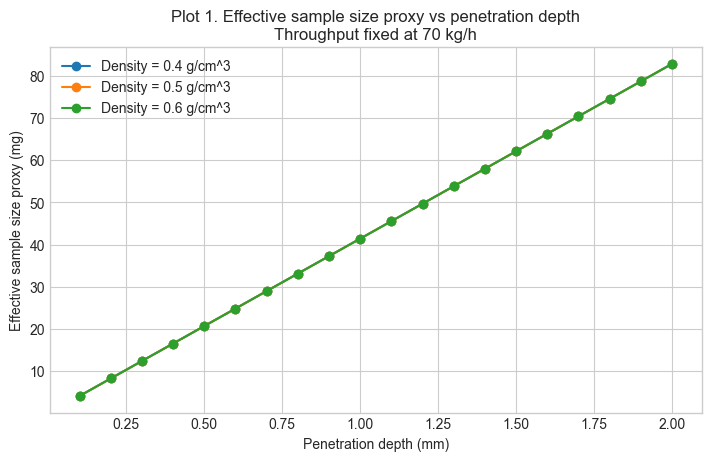

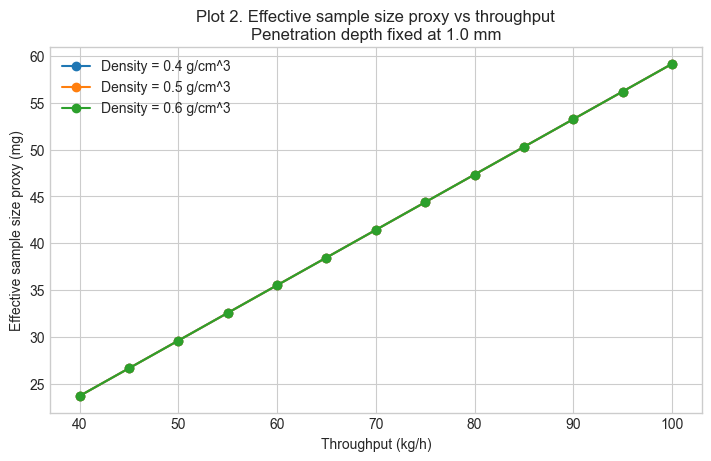

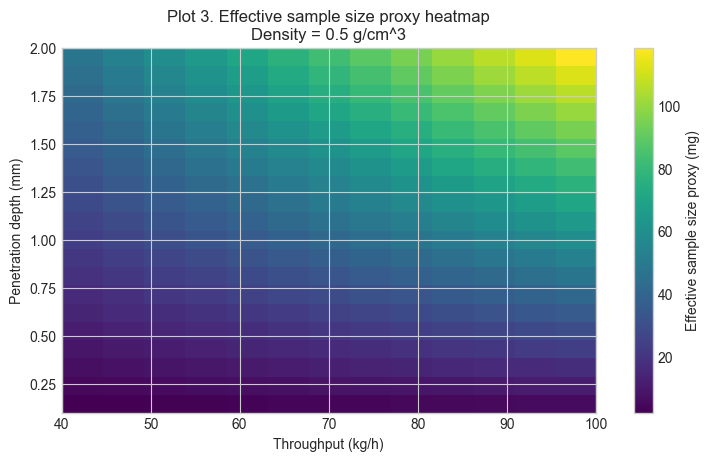

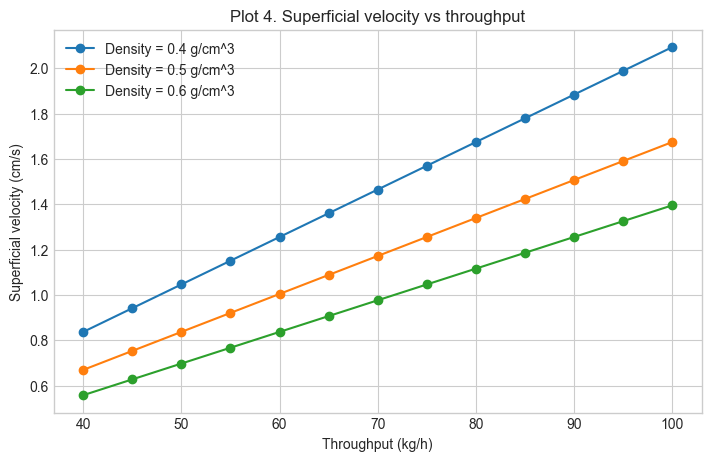

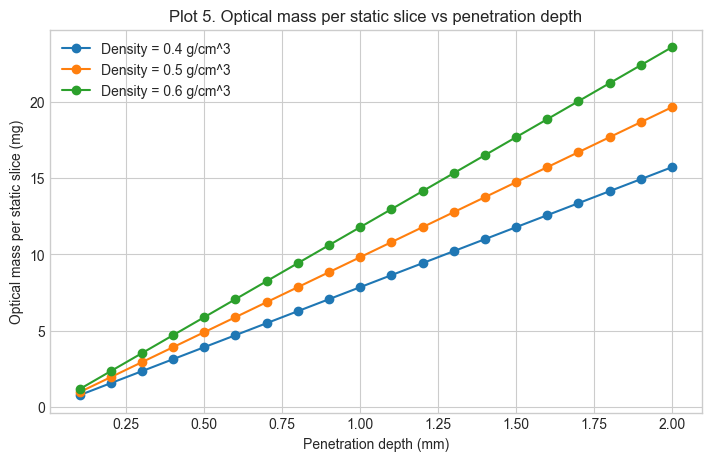

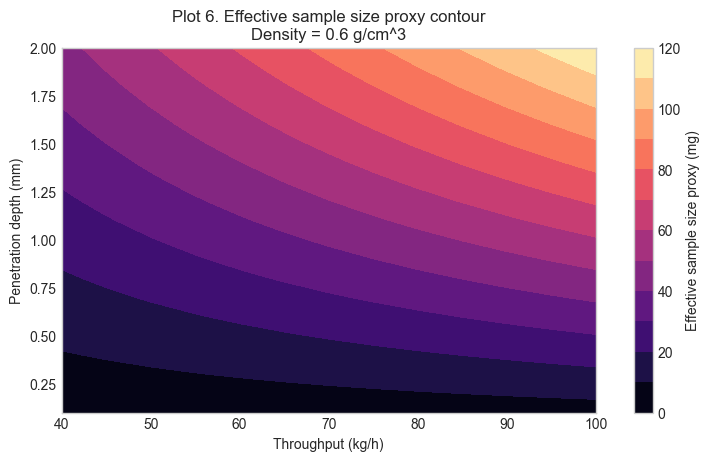

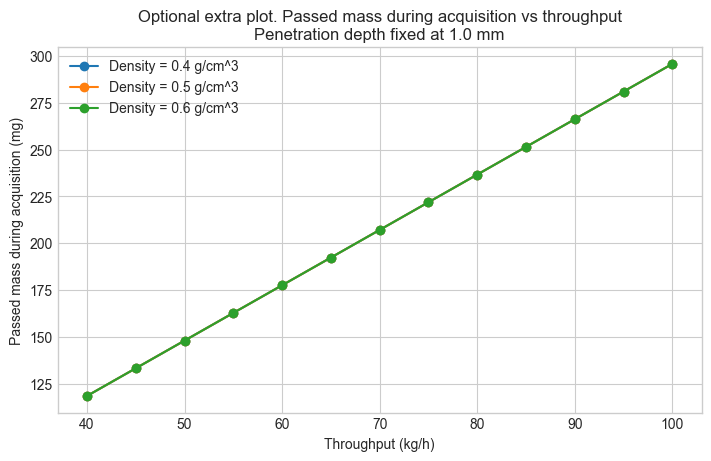

In [ ]:
# Plot 1: effective estimate vs penetration depth at fixed throughput
fig_setup_d_plot_01, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
plot1_df = results_df[results_df['throughput_kg_h'] == 70]
for density in density_values_g_cm3:
    subset = plot1_df[plot1_df['density_g_cm3'] == density]
    ax.plot(
        subset['penetration_depth_mm'],
        subset['effective_sample_mass_estimate_mg'],
        marker='o',
        label=f'Density = {density:.1f} g/cm^3',
    )
ax.set_title('Plot 1. Effective sample size estimate vs penetration depth\nThroughput fixed at 70 kg/h')
ax.set_xlabel('Penetration depth (mm)')
ax.set_ylabel('Effective sample size estimate (mg)')
ax.legend()
plt.show()

# Plot 2: effective estimate vs throughput at fixed penetration depth
fig_setup_d_plot_02, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
plot2_df = results_df[np.isclose(results_df['penetration_depth_mm'], 1.0)]
for density in density_values_g_cm3:
    subset = plot2_df[plot2_df['density_g_cm3'] == density]
    ax.plot(
        subset['throughput_kg_h'],
        subset['effective_sample_mass_estimate_mg'],
        marker='o',
        label=f'Density = {density:.1f} g/cm^3',
    )
ax.set_title('Plot 2. Effective sample size estimate vs throughput\nPenetration depth fixed at 1.0 mm')
ax.set_xlabel('Throughput (kg/h)')
ax.set_ylabel('Effective sample size estimate (mg)')
ax.legend()
plt.show()

# Plot 3: heatmap for density 0.5 g/cm^3
fig_setup_d_plot_03, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
im = ax.imshow(
    pivot_density_05.values,
    aspect='auto',
    origin='lower',
    extent=[
        pivot_density_05.columns.min(),
        pivot_density_05.columns.max(),
        pivot_density_05.index.min(),
        pivot_density_05.index.max(),
    ],
    cmap='viridis',
)
ax.set_title('Plot 3. Effective sample size estimate heatmap\nDensity = 0.5 g/cm^3')
ax.set_xlabel('Throughput (kg/h)')
ax.set_ylabel('Penetration depth (mm)')
fig_setup_d_plot_03.colorbar(im, ax=ax, label='Effective sample size estimate (mg)')
plt.show()

# Plot 4: superficial velocity vs throughput
fig_setup_d_plot_04, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
velocity_plot_df = (
    results_df[['throughput_kg_h', 'density_g_cm3', 'superficial_velocity_cm_s']]
    .drop_duplicates()
    .sort_values(['density_g_cm3', 'throughput_kg_h'])
)
for density in density_values_g_cm3:
    subset = velocity_plot_df[velocity_plot_df['density_g_cm3'] == density]
    ax.plot(
        subset['throughput_kg_h'],
        subset['superficial_velocity_cm_s'],
        marker='o',
        label=f'Density = {density:.1f} g/cm^3',
    )
ax.set_title('Plot 4. Superficial velocity vs throughput')
ax.set_xlabel('Throughput (kg/h)')
ax.set_ylabel('Superficial velocity (cm/s)')
ax.legend()
plt.show()

# Plot 5: optical mass per static slice vs penetration depth
fig_setup_d_plot_05, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
plot5_df = results_df[results_df['throughput_kg_h'] == 70]
for density in density_values_g_cm3:
    subset = plot5_df[plot5_df['density_g_cm3'] == density]
    ax.plot(
        subset['penetration_depth_mm'],
        subset['optical_mass_per_refresh_mg'],
        marker='o',
        label=f'Density = {density:.1f} g/cm^3',
    )
ax.set_title('Plot 5. Optical mass per static slice vs penetration depth')
ax.set_xlabel('Penetration depth (mm)')
ax.set_ylabel('Optical mass per static slice (mg)')
ax.legend()
plt.show()

# Plot 6: contour plot for density 0.6 g/cm^3
fig_setup_d_plot_06, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
T, P = np.meshgrid(pivot_density_06.columns.to_numpy(), pivot_density_06.index.to_numpy())
contour = ax.contourf(T, P, pivot_density_06.values, levels=12, cmap='magma')
ax.set_title('Plot 6. Effective sample size estimate contour\nDensity = 0.6 g/cm^3')
ax.set_xlabel('Throughput (kg/h)')
ax.set_ylabel('Penetration depth (mm)')
fig_setup_d_plot_06.colorbar(contour, ax=ax, label='Effective sample size estimate (mg)')
plt.show()

fig_setup_d_passed_mass, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
extra_plot_df = results_df[np.isclose(results_df['penetration_depth_mm'], 1.0)]
for density in density_values_g_cm3:
    subset = extra_plot_df[extra_plot_df['density_g_cm3'] == density]
    ax.plot(
        subset['throughput_kg_h'],
        subset['passed_mass_mg'],
        marker='o',
        label=f'Density = {density:.1f} g/cm^3',
    )
ax.set_title('Optional extra plot. Passed mass during acquisition vs throughput\nPenetration depth fixed at 1.0 mm')
ax.set_xlabel('Throughput (kg/h)')
ax.set_ylabel('Passed mass during acquisition (mg)')
ax.legend()
plt.show()

## 13. Interpretation of trends

Several clear trends appear in this first-order model.

- Increasing **density** increases the **optical mass per static slice** linearly because $m_{\mathrm{opt}} = \rho A_{\mathrm{probe}} d_{\mathrm{pen}}$.
- Increasing **penetration depth** increases the **optical mass per static slice** linearly because the modeled optical volume grows linearly with depth.
- Increasing **throughput** increases the **superficial velocity** linearly for fixed density and pipe area.
- Increasing superficial velocity decreases the **crossing time** and therefore increases the **refresh count** during one acquisition.
- The result should be interpreted as a **flow-based refreshed optical mass estimate**, not necessarily an independent sampling mass.

### Why density cancels completely: mechanistic explanation

In this model, density enters in two places that work in opposite directions. The two effects have exactly equal magnitude and cancel each other.

**Effect 1 — more mass per snapshot.** A denser powder packs more grams into the same optical cylinder in front of the probe. The static optical mass scales linearly with density:

$$
m_{\mathrm{opt}} = \rho \cdot A_{\mathrm{probe}} \cdot d_{\mathrm{pen}}
$$

Doubling the density doubles the mass the probe sees at any instant.

**Effect 2 — slower flow, fewer refreshes.** The pipe must deliver the same mass throughput $\dot{m}$ (in kg/h). If the powder is denser, fewer cubic centimeters per second are needed to carry that mass. The superficial velocity is inversely proportional to density:

$$
v = \frac{\dot{m}}{\rho \cdot A_{\mathrm{pipe}}}
$$

Doubling the density halves the velocity, which halves the number of probe-diameter crossings during the acquisition, and therefore halves the refresh count.

**Net result.** Twice the mass per refresh multiplied by half as many refreshes gives the same total:

$$
m_{\mathrm{eff}} = \underbrace{\rho \cdot A_{\mathrm{probe}} \cdot d_{\mathrm{pen}}}_{\text{mass per refresh}} \;\times\; \underbrace{\frac{t_{\mathrm{acq}} \cdot v}{d_{\mathrm{probe}}}}_{\text{number of refreshes}}
$$

Substituting $v = \dot{m}/(\rho \, A_{\mathrm{pipe}})$, the $\rho$ in the numerator from optical mass and the $1/\rho$ from velocity cancel exactly:

$$
m_{\mathrm{eff}} = \frac{A_{\mathrm{probe}} \, d_{\mathrm{pen}} \, t_{\mathrm{acq}}}{d_{\mathrm{probe}} \, A_{\mathrm{pipe}}} \cdot \dot{m}
$$

No $\rho$ remains. The effective sample size estimate depends only on mass throughput, geometry, and acquisition time.

**Physical intuition.** The probe footprint acts as a small window in a pipe carrying a fixed mass flow. During one acquisition, a certain mass of powder is transported past that window. That transported mass depends on how much of the pipe's total mass flow is intercepted by the probe footprint (the geometric ratio $A_{\mathrm{probe}} / A_{\mathrm{pipe}}$), how long the acquisition lasts ($t_{\mathrm{acq}}$), and an optical depth scaling ($d_{\mathrm{pen}} / d_{\mathrm{probe}}$). None of these involve density. Whether the stream is a slow trickle of dense material or a faster flow of light material, the mass flux through the probe window is the same because $\rho \cdot v = \dot{m} / A_{\mathrm{pipe}}$ depends only on throughput and pipe geometry.

**Why this is a model property, not a universal physical truth.** The cancellation is exact only because the model assumes: (1) the full pipe cross-section carries flow uniformly, (2) density is spatially uniform, and (3) the velocity at the probe equals the cross-sectional average. In reality, density would re-enter through any of these mechanisms:

- **Filling fraction:** a denser powder may fill a smaller cross-sectional fraction of the tilted pipe, changing $A_{\mathrm{flowing}}$ and therefore the actual local velocity.
- **Wall friction:** denser powders may have different friction coefficients against the pipe wall, altering the local velocity where the probe sits.
- **Consolidation:** denser powder may compact more under its own weight, creating a local density at the probe that differs from the bulk average.
- **Flow regime transitions:** at extreme densities the flow could transition between sliding, rolling, and slug regimes, each with different renewal characteristics.

## 14. Model limitations

Important limitations of this notebook are:

- the cylindrical optical volume is only an approximation
- there is no radiative-transfer model and no photon weighting with depth
- superficial velocity may differ from the true local wall velocity at the probe location
- the 26.5 degree tilt is represented only qualitatively in the base model
- there is no correction for asymmetric sliding-layer thickness
- there is no correction for stagnant regions or wall slip
- there is no model for powder compaction or de-aeration along the pipe length
- there is no correction for intermittent flow or slug behavior at low throughputs
- there is no particle size or particle count model
- there is no recirculation correction
- the model is not linked directly to analytical variance or Gy sampling theory

Useful future refinements could include:

- an effective moving-layer thickness
- a local wall velocity factor
- a filling fraction or flowing cross-sectional area correction
- a residence-time or particle revisit model
- a compaction or de-aeration model for the powder state along the pipe
- a coverage model for intermittent or slug-like flow at low throughputs

## 15. Conclusions

This notebook estimates a **first-order flow-based effective sample size estimate** for Setup D, expressed as refreshed optical mass during one spectrum acquisition.

Within this model, the strongest explicit drivers are:

- **throughput**, which sets superficial velocity and refresh rate
- **penetration depth**, which scales the optical mass per refresh
- **probe and pipe geometry**, which determine the footprint and renewal scale

The notebook is useful for **sensitivity analysis**, quick scenario comparison, and engineering intuition during development. A more advanced model could incorporate local lower-wall flow kinematics, effective moving-layer thickness, nonuniform filling, revisit behavior, and optical depth weighting.

## Export and Reporting

This export section writes timestamped CSV, PNG, JSON, and Word outputs into the setup-specific `reports/` folder. `python-docx` and `nbformat` are required for Word export with Markdown rendering.

In [ ]:

from pathlib import Path
import importlib
import sys

# Resolve project root dynamically (notebooks live in <project>/notebooks/)
try:
    project_root = Path(__vsc_ipynb_file__).resolve().parent.parent
except NameError:
    project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.reporting_utils as reporting_utils
reporting_utils = importlib.reload(reporting_utils)

build_word_report = reporting_utils.build_word_report
create_run_directory = reporting_utils.create_run_directory
save_dataframes_dict = reporting_utils.save_dataframes_dict
save_figures_dict = reporting_utils.save_figures_dict
write_metadata_json = reporting_utils.write_metadata_json

setup_name = "setup_d"
notebook_filename = "setup_D_pipe_effective_sample_size.ipynb"
notebook_path = project_root / "notebooks" / notebook_filename
report_filename = "setup_d_report.docx"

timestamp, run_dir = create_run_directory(project_root, setup_name)

summary_table_df = selected_scenarios.copy()
velocity_summary_df = (
    results_df[["throughput_kg_h", "density_g_cm3", "superficial_velocity_cm_s", "passed_mass_mg"]]
    .drop_duplicates()
    .sort_values(["density_g_cm3", "throughput_kg_h"])
    .reset_index(drop=True)
)

dataframes_to_save = {
    "results_full": results_df,
    "summary_table": summary_table_df,
    "velocity_summary": velocity_summary_df,
}
figures_to_save = {
    "plot_01_estimate_vs_penetration_depth": globals().get("fig_setup_d_plot_01"),
    "plot_02_estimate_vs_throughput": globals().get("fig_setup_d_plot_02"),
    "plot_03_heatmap_density_05": globals().get("fig_setup_d_plot_03"),
    "plot_04_superficial_velocity_vs_throughput": globals().get("fig_setup_d_plot_04"),
    "plot_05_optical_mass_per_refresh": globals().get("fig_setup_d_plot_05"),
    "plot_06_contour_density_06": globals().get("fig_setup_d_plot_06"),
    "plot_07_passed_mass_vs_throughput": globals().get("fig_setup_d_passed_mass"),
}

csv_files = save_dataframes_dict(dataframes_to_save, run_dir)
png_files = save_figures_dict(figures_to_save, run_dir, dpi=300)

parameter_summary = {
    "Pipe diameter (mm)": pipe_diameter_mm,
    "Pipe tilt from vertical (deg)": pipe_tilt_deg_from_vertical,
    "Pipe total height (mm)": pipe_total_height_mm,
    "Inlet-outlet displacement (mm)": pipe_inlet_outlet_displacement_mm,
    "Probe diameter (mm)": probe_diameter_mm,
    "Acquisition time (s)": acquisition_time_s,
    "Throughput range (kg/h)": f"{min(throughput_values_kg_h)} to {max(throughput_values_kg_h)}",
    "Density scenarios (g/cm^3)": [float(x) for x in density_values_g_cm3],
    "Penetration depth range (mm)": f"{penetration_depth_values_mm.min():.1f} to {penetration_depth_values_mm.max():.1f}",
}
purpose_text = (
    "Setup D estimates a first-order flow-based effective sample size estimate in a tilted pipe by combining optical "
    "mass per refresh with a refresh rate derived from superficial velocity."
)
assumptions_text = (
    "Superficial velocity is used as a first-order flow approximation, density is uniform within each scenario, "
    "the optical volume is cylindrical, and the tilt effect is captured only through the stated simplified geometry."
)
metadata = {
    "setup_name": setup_name,
    "timestamp": timestamp,
    "notebook_filename": notebook_filename,
    "report_filename": report_filename,
    "csv_files": csv_files,
    "png_files": png_files,
    "key_parameters": parameter_summary,
}
write_metadata_json(metadata, run_dir / "metadata.json")

# --- Content sections for detailed Word report ---
_we_velocity = effective_estimate['superficial_velocity_cm_s']
_we_thr_g_s = kg_h_to_g_s(worked_example_throughput_kg_h)
_we_passed_vol = passed_volume_cm3(
    _we_velocity, mm_to_cm(probe_diameter_mm), acquisition_time_s
)
_we_passed_mass_val = passed_mass_mg(
    worked_example_density_g_cm3, _we_velocity,
    mm_to_cm(probe_diameter_mm), acquisition_time_s,
)

worked_example_body = (
    f"The worked example uses:\n\n"
    f"- throughput = **{worked_example_throughput_kg_h} kg/h**\n"
    f"- density = **{worked_example_density_g_cm3} g/cm\u00b3**\n"
    f"- pipe diameter = **{pipe_diameter_mm:.0f} mm**\n"
    f"- pipe tilt = **{pipe_tilt_deg_from_vertical} degrees from vertical**\n"
    f"- pipe total height = **{pipe_total_height_mm:.0f} mm**\n"
    f"- horizontal displacement = **{pipe_inlet_outlet_displacement_mm} mm**\n"
    f"- probe diameter = **{probe_diameter_mm} mm**\n"
    f"- penetration depth = **{worked_example_penetration_depth_mm} mm**\n"
    f"- acquisition time = **{acquisition_time_s} s**\n\n"
    f"This example should be interpreted as a **first-order estimate**. In a real tilted pipe, "
    f"the local velocity at the lower wall may differ from the superficial velocity because the "
    f"flowing layer can be asymmetric and concentrated near the lower side.\n\n"
    f"### Computed results\n\n"
    f"- Pipe cross-sectional area: {pipe_area_cm2:.4f} cm\u00b2\n"
    f"- Throughput: {_we_thr_g_s:.4f} g/s\n"
    f"- Superficial velocity: {_we_velocity:.4f} cm/s\n"
    f"- Probe area: {probe_area_value_cm2:.6f} cm\u00b2\n"
    f"- Optical volume per static slice: {optical_volume_value_cm3:.6f} cm\u00b3\n"
    f"- Optical mass per static slice: {optical_mass_value_g * 1000.0:.4f} mg\n"
    f"- Crossing time: {crossing_time_value_s:.4f} s\n"
    f"- Number of refreshes: {n_refresh_value:.4f}\n"
    f"- Effective sample size estimate: {effective_estimate['effective_sample_mass_estimate_mg']:.4f} mg\n"
    f"- Passed volume during acquisition: {_we_passed_vol:.6f} cm\u00b3\n"
    f"- Passed mass during acquisition: {_we_passed_mass_val:.4f} mg\n"
)

parameter_sweep_body = (
    f"The full parameter sweep spans:\n\n"
    f"- throughput from **{min(throughput_values_kg_h)} to {max(throughput_values_kg_h)} kg/h** in 5 kg/h steps\n"
    f"- density = **{', '.join(str(d) for d in density_values_g_cm3)} g/cm\u00b3**\n"
    f"- penetration depth from **{penetration_depth_values_mm.min():.1f} to "
    f"{penetration_depth_values_mm.max():.1f} mm** in 0.1 mm steps\n"
    f"- probe diameter fixed at **{probe_diameter_mm} mm**\n"
    f"- acquisition time fixed at **{acquisition_time_s} s**\n\n"
    f"Generated **{len(results_df)}** modeled scenarios."
)

interpretation_body = (
    "Several clear trends appear in this first-order model.\n\n"
    "- Increasing **density** increases the **optical mass per static slice** linearly "
    "because the optical volume is scaled by density.\n"
    "- Increasing **penetration depth** increases the **optical mass per static slice** linearly "
    "because the modeled optical volume grows linearly with depth.\n"
    "- Increasing **throughput** increases the **superficial velocity** linearly "
    "for fixed density and pipe area.\n"
    "- Increasing superficial velocity decreases the **crossing time** and therefore "
    "increases the **refresh count** during one acquisition.\n"
    "- The result should be interpreted as a **flow-based refreshed optical mass estimate**, "
    "not necessarily an independent sampling mass.\n\n"
    "### Why density cancels completely\n\n"
    "Density enters in two places that work in opposite directions with exactly equal magnitude. "
    "A higher density increases the static optical mass seen at one instant (more grams per "
    "cubic centimeter in the optical volume), but simultaneously reduces the superficial velocity "
    "in the same proportion (fewer cubic centimeters per second needed to deliver the same mass "
    "throughput). The larger mass per refresh and the smaller number of refreshes offset each "
    "other exactly.\n\n"
    "This complete cancellation is a direct consequence of the model structure. In a more "
    "realistic tilted-pipe model, density could re-enter through changes in flowing layer "
    "thickness, local wall velocity, consolidation, slip, or coverage dynamics."
)

limitations_body = (
    "Important limitations of this notebook are:\n\n"
    "- the cylindrical optical volume is only an approximation\n"
    "- there is no radiative-transfer model and no photon weighting with depth\n"
    "- superficial velocity may differ from the true local wall velocity at the probe location\n"
    "- the tilt angle is represented only qualitatively in the base model\n"
    "- there is no correction for asymmetric sliding-layer thickness\n"
    "- there is no correction for stagnant regions or wall slip\n"
    "- there is no model for powder compaction or de-aeration along the pipe length\n"
    "- there is no correction for intermittent flow or slug behavior at low throughputs\n"
    "- there is no particle size or particle count model\n"
    "- there is no recirculation correction\n"
    "- the model is not linked directly to analytical variance or Gy sampling theory\n\n"
    "Useful future refinements could include:\n\n"
    "- an effective moving-layer thickness\n"
    "- a local wall velocity factor\n"
    "- a filling fraction or flowing cross-sectional area correction\n"
    "- a residence-time or particle revisit model\n"
    "- a compaction or de-aeration model for the powder state along the pipe\n"
    "- a coverage model for intermittent or slug-like flow at low throughputs"
)

conclusions_body = (
    "This notebook estimates a **first-order flow-based effective sample size estimate** for Setup D, "
    "expressed as refreshed optical mass during one spectrum acquisition.\n\n"
    "Within this model, the strongest explicit drivers are:\n\n"
    "- **throughput**, which sets superficial velocity and refresh rate\n"
    "- **penetration depth**, which scales the optical mass per refresh\n"
    "- **probe and pipe geometry**, which determine the footprint and renewal scale\n\n"
    "The notebook is useful for **sensitivity analysis**, quick scenario comparison, and "
    "engineering intuition during development. A more advanced model could incorporate local "
    "lower-wall flow kinematics, effective moving-layer thickness, nonuniform filling, revisit "
    "behavior, and optical depth weighting."
)

content_sections = [
    {"heading": "Single-case worked example", "body": worked_example_body},
    {"heading": "Parameter sweep", "body": parameter_sweep_body},
    {"heading": "Visualization", "figures": png_files},
    {"heading": "Interpretation of trends", "body": interpretation_body},
    {"heading": "Model limitations", "body": limitations_body},
    {"heading": "Conclusions", "body": conclusions_body},
]

build_word_report(
    report_title="Setup D Effective Sample Size Report",
    setup_name=setup_name,
    timestamp=timestamp,
    run_dir=run_dir,
    notebook_path=notebook_path,
    purpose_text=purpose_text,
    assumptions_text=assumptions_text,
    parameter_summary=parameter_summary,
    csv_filenames=csv_files,
    figure_filenames=png_files,
    output_filename=report_filename,
    content_sections=content_sections,
)


print(f"Report run directory: {run_dir}")

Report run directory: C:\temp files\EFS\reports\setup_d\20260320_145157
